In [1]:
import glob
import os
from time import perf_counter

import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [2]:
from dev import fit_baseline, AsymmetricTukeyBiweight

In [3]:
%matplotlib inline

## Function definitions

In [4]:
def old_model(params, t, xp=np):
    """
    Baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray | jax.Array
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    # exponentials
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    # helper terms
    A = 1 + b_slow * E_slow + b_fast * E_fast
    B = 1 - b_bright * E_bright

    y = b_inf * A * B
    return y

In [5]:
def model(params, t, xp=np):
    """
    Baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray | jax.Array
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    return b_inf + b_slow * E_slow + b_fast * E_fast - b_bright * E_bright

def model_jac(
    params: np.ndarray,
    t: np.ndarray,
    xp=np,
    return_jac: bool = False,
) -> np.ndarray | jax.Array | tuple[np.ndarray, np.ndarray]:
    """
    Bright baseline with triphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_rapid, b_bright,
                           t_slow, t_fast, t_rapid, t_bright].
        ``b_inf``            — asymptotic (t→∞) baseline level.
        ``b_slow``, ``b_fast``, ``b_rapid`` — bleaching amplitudes (> 0).
        ``b_bright``         — brightening amplitude (> 0); signal starts
                               suppressed by ``b_bright`` and recovers.
        ``t_slow``, ``t_fast``, ``t_rapid``, ``t_bright`` — time constants.
    t : np.ndarray
        Timestamps.
    xp : module, optional
        Array namespace to use. Pass ``jnp`` for JAX tracing, default ``np``.
    return_jac : bool, optional
        If True, return Jacobian alongside the model prediction.
        Ignored when ``xp is jnp``; use autodiff instead.

    Returns
    -------
    y : np.ndarray
        Model prediction.
    J : np.ndarray, optional
        Jacobian with respect to parameters (returned if return_jac=True).
    """
    b_inf, b_slow, b_fast, b_bright, t_slow, t_fast, t_bright = params
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    y = b_inf + b_slow * E_slow + b_fast * E_fast - b_bright * E_bright
    if not return_jac:
        return y

    J = np.empty((t.size, 9))
    J[:, 0] = 1.0  # d/d b_inf
    J[:, 1] = E_slow  # d/d b_slow
    J[:, 2] = E_fast  # d/d b_fast
    J[:, 3] = -E_bright  # d/d b_bright
    J[:, 4] = b_slow / t_slow**2 * (E_slow * t)  # d/d t_slow
    J[:, 5] = b_fast / t_fast**2 * (E_fast * t)  # d/d t_fast
    J[:, 6] = -b_bright / t_bright**2 * (E_bright * t)  # d/d t_bright
    return y, J

In [6]:
def log_model(params, t, xp=np):
    """
    Baseline with biphasic decay and saturating brightening.

    Parameters
    ----------
    params : np.ndarray
        Parameter vector: [b_inf, b_slow, b_fast, b_bright,
                           t_slow, t_fast, t_bright]
    t : np.ndarray
        Timestamps

    Returns
    -------
    y : np.ndarray | jax.Array
        Model prediction
    """
    b_inf, b_slow, b_fast, b_bright = params[:4]
    t_slow, t_fast, t_bright = xp.exp(params[4:])
    E_slow = xp.exp(-t / t_slow)
    E_fast = xp.exp(-t / t_fast)
    E_bright = xp.exp(-t / t_bright)
    return b_inf + b_slow * E_slow + b_fast * E_fast - b_bright * E_bright

In [7]:
def plot_dff(F, F0, F0trend, t=None, zoom_duration=60.0):
    if t is None:
        t = np.arange(len(F))
    show_insets = zoom_duration is not None and zoom_duration > 0
    if show_insets:
        fig, ax=plt.subplots(5,1,figsize=(15,6), sharex=True)
    else:
        fig, ax=plt.subplots(4,1,figsize=(15,5), sharex=True)
    ax[0].plot(t, trace, label="$F$")
    ax[0].plot(t, F0trend, label="$F0_{trend}$")
    ax[0].plot(t, F0, label="$F0$")
    ax[0].set_ylabel("$F$ [a.u.]")
    ax[1].plot(t, trace-F0trend, c="C1", label="$F-F0_{trend}$")
    ax[1].axhline(0, ls="--", c="k")
    ax[1].plot(t, F0-F0trend, c="C2", label="$F0_{fluctuations}$")
    ax[1].set_ylabel("$\\Delta F$ [a.u.]")
    ax[2].plot(t, 100 * (trace/F0trend-1), c="C1", label="$\\frac{\\Delta F_{trend}}{F0_{trend}}$")
    ax[2].axhline(0, ls="--", c="k")
    ax[2].set_ylabel(r"$\Delta$F/F [%]")
    ax[3+show_insets].plot(t, 100 * (trace/F0trend-1), c="C2", label="$\\frac{\\Delta F}{F}$")
    ax[3+show_insets].axhline(0, ls="--", c="k")
    ax[3+show_insets].set_ylabel(r"$\Delta$F/F [%]", y=1 if show_insets else 0.5)
    for a in ax[:3]:
        a.legend(loc=1)
    ax[-1].legend(loc=1)
    
    # Add insets if requested
    if show_insets:
        t_total = t[-1] - t[0]
        dff_trace = F/F0 - 1
        zoom_windows = [
            (t[0], t[0] + zoom_duration),
            (
                t[0] + (t_total - zoom_duration) / 2,
                t[0] + (t_total + zoom_duration) / 2,
            ),
            (max(t[-1] - zoom_duration, t[0]), t[-1]),
        ]
    
        ax[3].axis("off")
    
        for j, (start_time, end_time) in enumerate(zoom_windows):
            inset_ax = inset_axes(
                ax[3],
                width="100%",
                height="100%",
                loc="center",
                bbox_to_anchor=([0.01, 0.34, 0.67][j], 0.0, 0.32, 0.8),
                bbox_transform=ax[3].transAxes,
            )
    
            mask = (t >= start_time) & (t <= end_time)
            if np.any(mask):
                t_zoom, dff_zoom = t[mask], dff_trace[mask] * 100
    
                inset_ax.plot(t_zoom, dff_zoom, c="C2", lw=0.5)
                inset_ax.axhline(0, c="k", ls="--")
                inset_ax.grid(True, alpha=0.8)
                inset_ax.set_xlim(start_time, end_time)
    
                if len(dff_zoom) > 0:
                    mi, ma = np.nanmin(dff_zoom), np.nanmax(dff_zoom)
                    y_margin = 0.1 * (ma - mi)
                    if ~np.isnan(y_margin):
                        inset_ax.set_ylim(mi - y_margin, ma + y_margin)
    
                inset_ax.set_title(
                    f"{['First', 'Middle', 'Last'][j]} {zoom_duration:.0f}s",
                    fontsize=10,
                    y=0.94,
                )
                inset_ax.set_xticks([])
                inset_ax.set_yticks([])
    
                mark_inset(
                    ax[4],
                    inset_ax,
                    loc1=1,
                    loc2=3,
                    fc="none",
                    ec="#333333",
                    alpha=0.8,
                    linestyle="--",
                    linewidth=1,
                )
        
    a.set_xlim(-.01*t[-1], 1.01*t[-1])
    ax[-1].set_xlabel("Time [frames]" if t[1]==1 else "Time [s]")
    plt.subplots_adjust(hspace=0.1, top=0.935, bottom=0.13, left=0.06, right=0.995)

In [8]:
def get_valid_corrected_f(path):
    dr = path.split("/")[-1]
    data = []
    with h5py.File(f"{path}/{dr}_data.h5") as f:
        for k in f['planes'].keys():
            data.append(f[f'planes/{k}/corrected_f'][f[f'planes/{k}/valid_roi_inds'][:]])
    return data

## Data 

In [9]:
dirs = glob.glob("/data/test-dataset-for-dff_multiplane-ophys_02/*/*")
dirs

['/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/804670',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/775682',
 '/data/test-dataset-for-dff_multiplane-ophys_02/lamf_slc32a1_oi1/782149',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753562',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/729088',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/758265',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/753561',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi4/724567',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/755212',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/759075',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/726433',
 '/data/test-dataset-for-dff_multiplane-ophys_02/snap25_oi4_dox/747443',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/757436',
 '/data/test-dataset-for-dff_multiplane-ophys_02/slc32a1_oi1/69

In [10]:
traces = get_valid_corrected_f(dirs[0])

In [11]:
trace = traces[0][0]

In [12]:
frame_rate = 10.63  # looked up manually from session.json of multiplane-ophys_804670_2025-09-24_09-30-56_processed_2025-10-10_22-28-44
timestamps = np.arange(len(trace)) / frame_rate

## fit baseline fluctuations

old_model

numpy  Time=56.0464s  Losses=16989.76, 16293.47 [8.54e+01 3.84e+01 3.15e+02 9.56e-01 4.52e+03 1.58e+02 3.48e+03] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 2.0268s  Losses=18707.26, 16268.34 [1.09e+03 2.72e-01 2.65e+00 6.73e-01 3.60e+03 2.40e+02 2.00e+03] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 8.5785s  Losses=17346.62, 16295.23 [5.22e+00 2.53e+03 2.19e+04 9.90e-01 3.28e+03 1.55e+02 1.40e+04] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


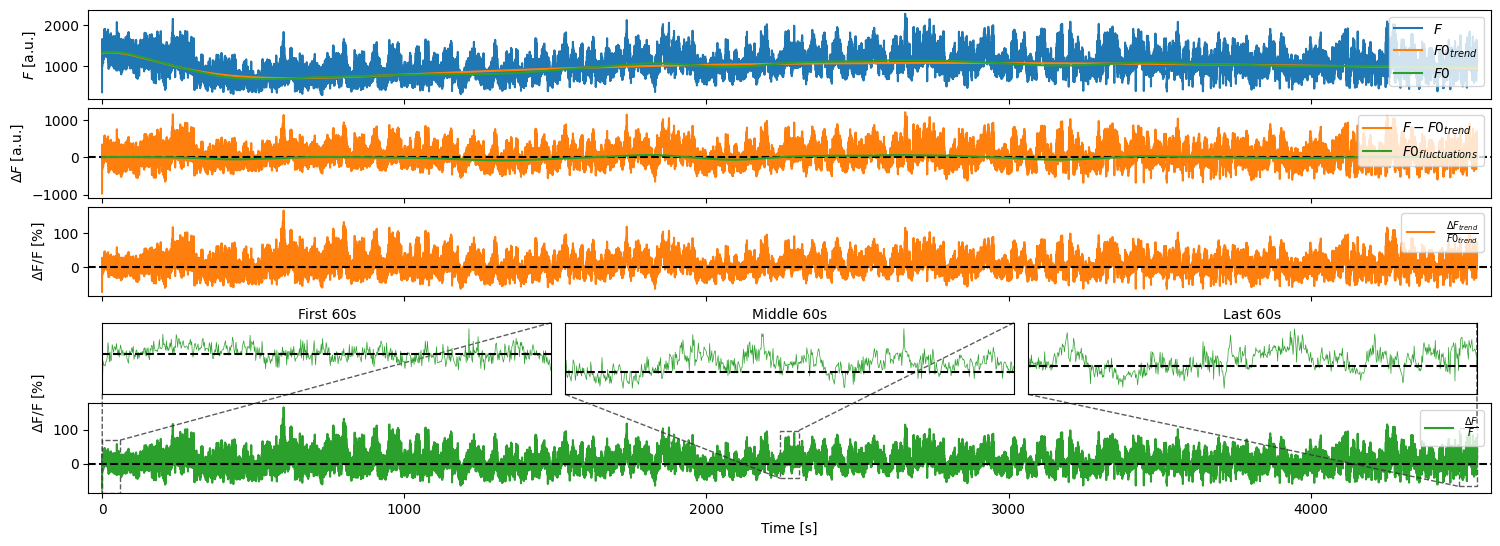

model

numpy  Time=13.7631s  Losses=17046.75, 16307.06 [  813.75  4287.25  6465.88 10098.03  1516.74   568.65   913.31] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 1.0561s  Losses=17030.60, 16318.20 [ 618.43 1348.65 5992.75 6488.29 3395.99  536.5   774.62] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 5.9437s  Losses=17383.21, 16308.27 [   862.02  30879.07 318190.38 348465.4    1026.67    784.72    805.71] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


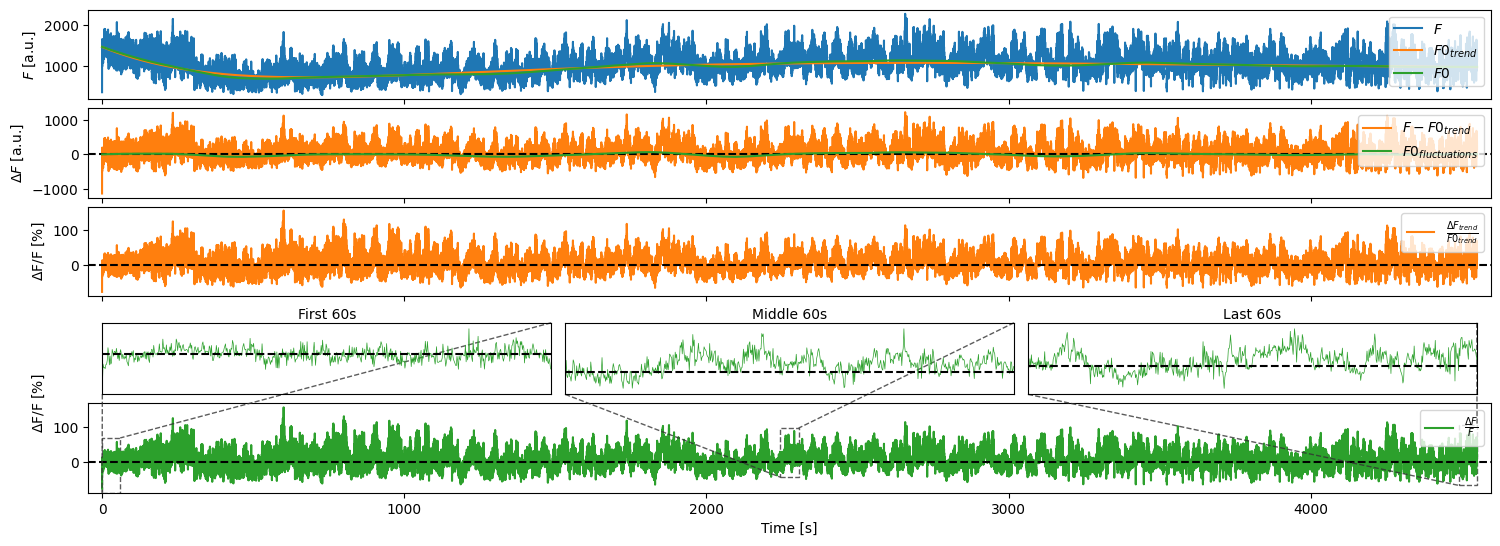

log_model



/tmp/ipykernel_5555/558186901.py:19: RuntimeWarning: overflow encountered in exp
  t_slow, t_fast, t_bright = xp.exp(params[4:])


numpy  Time=11.2953s  Losses=17401.40, 16319.10 [ 1038.19    12.59 11072.35 10602.66   420.31   409.24   459.76] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax32  Time= 1.7124s  Losses=18634.28, 16362.44 [1.14e+03 1.29e+00 2.28e+04 2.24e+04 3.08e+02 5.06e+02 5.42e+02] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
jax64  Time= 2.5117s  Losses=17399.29, 16319.65 [ 1038.12    37.69 25500.78 25056.27   439.71   423.03   444.68] CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


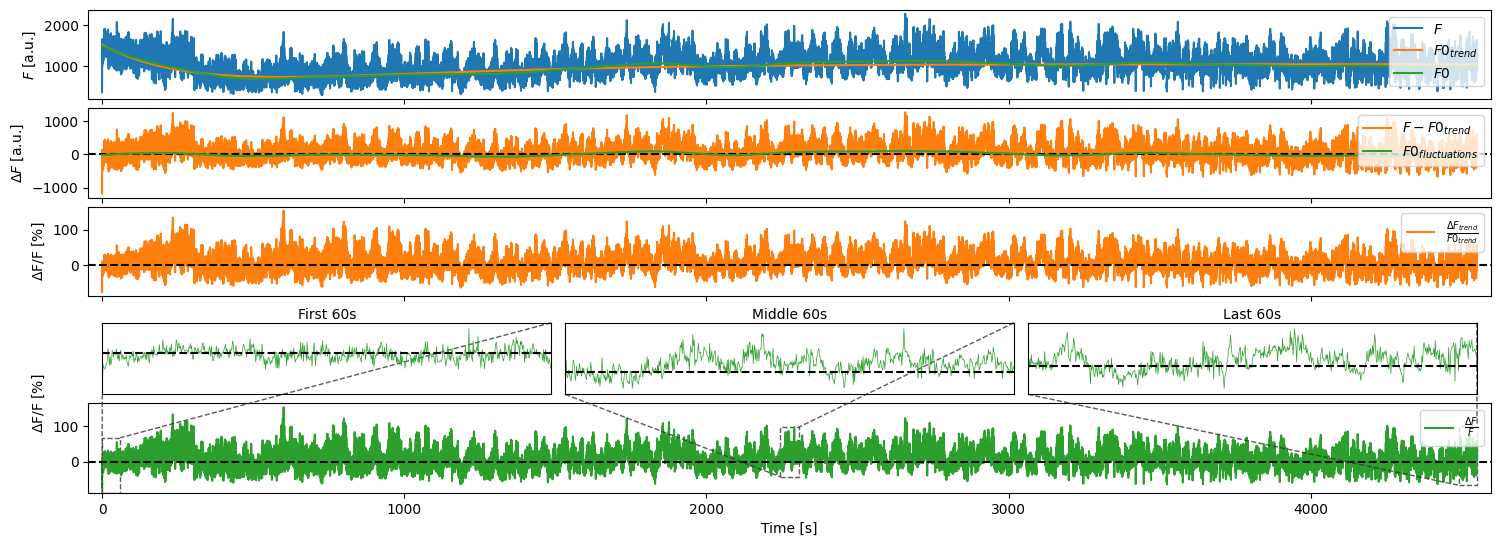

In [13]:
M = AsymmetricTukeyBiweight(2, 3)
bounds = [(0, None)] * 4 + [(300, None), (1, 1200), (1, None)]

for m, init in ((old_model, [trace[-1000:].mean(), 0.35, 0.2, 0.99, 3600, 240, 2000]),
                (model, [trace[-1000:].mean(), 350, 200, 10, 3600, 240, 2000]),
                (log_model, [trace[-1000:].mean(), 350, 200, 10, np.log(3600), np.log(240), np.log(2000)])):
    print(f"{m.__name__}\n")
    b = np.array(bounds.copy())
    if m.__name__ == "log_model":
        def log_bound(b):
            return None if b is None else np.log(b)
        b[4:] = [(log_bound(lo), log_bound(hi)) for lo, hi in b[4:]]
    for method in ("numpy", "jax32", "jax64"):
        dtype = jnp.float32 if method[-2:] == "32" else jnp.float64
        backend = "jax" if method[:3] == "jax" else method
        t0 = perf_counter()
        F0, F0trend, res, info = fit_baseline(trace, timestamps, m, init, b, M=M, backend=backend, dtype=dtype)
        ls = info['lowess_sigma']*F0trend
        loss = np.mean(M.rho((trace - F0) / ls) * ls**2)
        if m.__name__ == "log_model":
            res.x[4:] = np.exp(res.x[4:])
        with np.printoptions(precision=2, suppress=False, linewidth=120):
            print(f"{method}  Time={perf_counter()-t0:7.4f}s  "
                  f"Losses={res.fun/trace.size*res.sigma**2:.2f}, {loss:.2f}", res.x, res.message)
    plot_dff(trace, F0, F0trend, t=timestamps, zoom_duration=60.0)
    plt.show()

#### multiple traces in parallel

In [14]:
init = [trace[-1000:].mean(), 350, 200, 10, 3600, 240, 2000]
n_jobs = min(len(traces[0]), int(os.getenv("CO_CPUS", -1)))

for method in ("numpy", "np_jac", "jax32", "jax64"):
    dtype = jnp.float32 if method[-2:] == "32" else jnp.float64
    backend = "jax" if method[:3] == "jax" else "numpy"
    m = model_jac if method == "np_jac" else model
    t0 = perf_counter()
    res = Parallel(n_jobs=n_jobs)(
                delayed(fit_baseline)(
                    t, timestamps, m, init, bounds=bounds,
                    M=AsymmetricTukeyBiweight(2, 3),
                    backend=backend, dtype=dtype)
                for t in traces[0]
            )
    losses_trend = [r[2].fun/trace.size*r[2].sigma**2 for r in res]
    losses = [np.mean(M.rho((trace - F0) / (ls:=r[3]['lowess_sigma']*r[1])) * ls**2) for r in res]
    with np.printoptions(precision=2, suppress=False, linewidth=120):
        print(f"{method:6}  Time={perf_counter()-t0:7.4f}s  "
              f"Losses={np.mean(losses_trend):.2f}, {np.mean(losses):.2f}")

numpy   Time=91.9761s  Losses=14906.28, 10249.66


/root/capsule/code/dev.py:561: RuntimeWarning: overflow encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:561: RuntimeWarning: invalid value encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:561: RuntimeWarning: overflow encountered in matmul
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:561: RuntimeWarning: overflow encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:561: RuntimeWarning: invalid value encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:561: RuntimeWarning: overflow encountered in matmul
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:561: RuntimeWarning: invalid value encountered in matmul
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:561: RuntimeWarning: overflow encountered in multiply
  return np.sum(r**2), -2.0 * J.T @ r
/root/capsule/code/dev.py:561: RuntimeWarning: 

np_jac  Time=110.1897s  Losses=15541.90, 10250.71
jax32   Time=32.1643s  Losses=15159.46, 10254.22


/opt/conda/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


jax64   Time=70.8648s  Losses=15628.42, 10250.84
